# Numerical derivatives from Taylor series

The derivative of a function is defined by the limit

$$f'(x)=\lim_{h\rightarrow 0}\frac{f(x+h)-f(x)}{h}.$$

On a computer we cannot take a limit: we must choose a finite step size $h$ and evaluate the function at a finite number of points. This creates two distinct sources of error:

1. **Truncation error:** a finite-difference formula keeps only part of an infinite Taylor series.
2. **Roundoff error:** floating-point numbers store only a finite number of significant digits.

Taylor series let us derive several finite-difference algorithms and predict how their truncation errors depend on $h$. We begin by expanding the function on either side of $x$:

$$f(x+h)=f(x)+h f'(x)+\frac{h^2}{2}f''(x)+\frac{h^3}{6}f'''(x)+\frac{h^4}{24}f^{(4)}(x)+\cdots,$$

$$f(x-h)=f(x)-h f'(x)+\frac{h^2}{2}f''(x)-\frac{h^3}{6}f'''(x)+\frac{h^4}{24}f^{(4)}(x)-\cdots.$$

The alternating signs in the second expansion are the key to understanding the different algorithms.

## Forward and backward differences

Subtracting $f(x)$ from the expansion of $f(x+h)$ and dividing by $h$ gives the **forward-difference** formula:

$$D_+f(x)\equiv\frac{f(x+h)-f(x)}{h},$$

with

$$D_+f(x)=f'(x)+\frac{h}{2}f''(x)+\frac{h^2}{6}f'''(x)+O(h^3).$$

Therefore $f'(x)=D_+f(x)-\frac{h}{2}f''(x)+O(h^2)$, and the leading truncation error is proportional to $h$. We call this a **first-order accurate** approximation and write its truncation error as $O(h)$.

Similarly, subtracting the expansion of $f(x-h)$ from $f(x)$ gives the **backward-difference** formula:

$$D_-f(x)\equiv\frac{f(x)-f(x-h)}{h},$$

with

$$D_-f(x)=f'(x)-\frac{h}{2}f''(x)+\frac{h^2}{6}f'''(x)+O(h^3).$$

The backward difference is also first-order accurate. Notice that its leading error has the opposite sign from the forward-difference error. These one-sided formulas are useful near the boundary of a data set, where function values may be available on only one side of the point of interest.

## Centered difference

Subtracting the complete Taylor series for $f(x-h)$ from the series for $f(x+h)$ cancels all even-derivative terms:

$$f(x+h)-f(x-h)=2h f'(x)+\frac{2h^3}{6}f'''(x)+\frac{2h^5}{120}f^{(5)}(x)+\cdots.$$

Dividing by $2h$ gives the **centered-difference** formula

$$D_0f(x)\equiv\frac{f(x+h)-f(x-h)}{2h},$$

and its Taylor expansion is

$$D_0f(x)=f'(x)+\frac{h^2}{6}f'''(x)+O(h^4).$$

The terms proportional to $h$ cancel, so the leading truncation error is proportional to $h^2$. The centered difference is therefore **second-order accurate**, $O(h^2)$. If $h$ is reduced by a factor of 10 while truncation error dominates, we expect the forward- and backward-difference errors to fall by roughly a factor of 10, but the centered-difference error to fall by roughly a factor of 100.

This higher accuracy is not free: a centered difference requires function values on both sides of $x$. At the endpoints of a tabulated interval, a one-sided formula or some other boundary treatment is needed.

## Geometric interpretation

Each finite difference is the slope of a secant line. The forward difference uses the points at $x$ and $x+h$; the backward difference uses $x-h$ and $x$; and the centered difference uses $x-h$ and $x+h$. The diagram below shows these three choices for the same function and the same step size. As $h$ decreases, the secant slopes approach the tangent slope—but, in floating-point arithmetic, making $h$ arbitrarily small eventually introduces the roundoff problem discussed next.

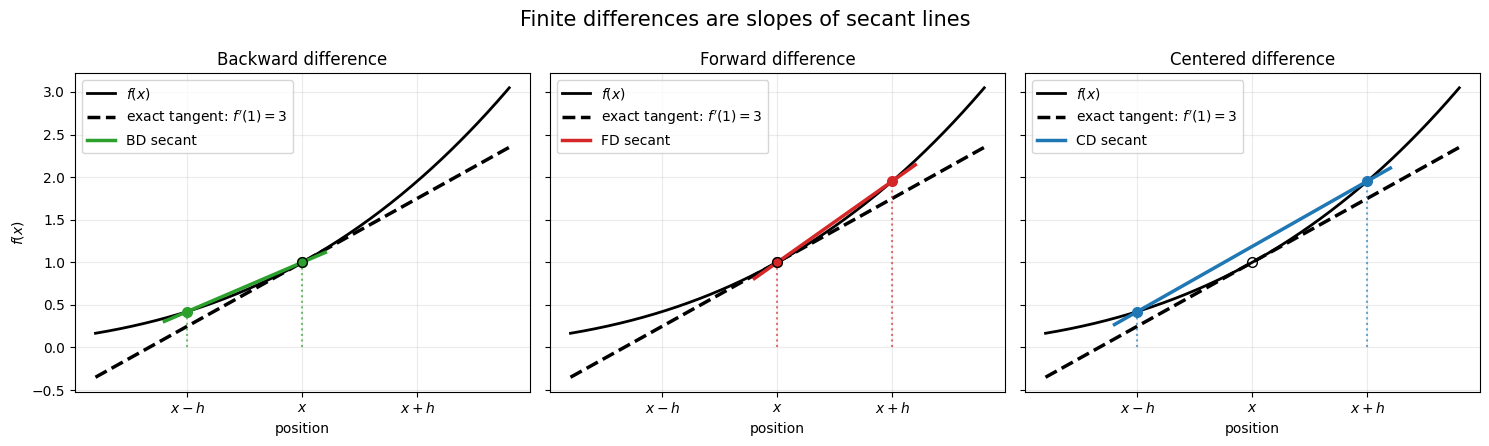

In [1]:
# Geometric view of forward, backward, and centered differences
import numpy as np
import matplotlib.pyplot as plt

def example_function(x):
    return x**3

x0 = 1.0
h_diagram = 0.25
x_curve = np.linspace(0.55, 1.45, 400)
exact_slope = 3.0
exact_tangent = example_function(x0)+exact_slope*(x_curve-x0)
function_color = 'black'

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
difference_diagrams = [
    ("Backward difference", x0-h_diagram, x0, "tab:green", "BD"),
    ("Forward difference", x0, x0+h_diagram, "tab:red", "FD"),
    ("Centered difference", x0-h_diagram, x0+h_diagram, "tab:blue", "CD"),
]

for ax, (title, x_left, x_right, color, abbreviation) in zip(axes, difference_diagrams):
    y_left = example_function(x_left)
    y_right = example_function(x_right)
    slope = (y_right-y_left)/(x_right-x_left)
    x_line = np.linspace(x_left-0.05, x_right+0.05, 50)
    y_line = y_left+slope*(x_line-x_left)

    ax.plot(x_curve, example_function(x_curve), color=function_color, linewidth=2,
            label=r'$f(x)$')
    ax.plot(x_curve, exact_tangent, color=function_color, linestyle='--',
            linewidth=2.5, label=r"exact tangent: $f'(1)=3$")
    ax.plot(x0, example_function(x0), marker='o', markersize=7,
            markerfacecolor='none', markeredgecolor=function_color, zorder=6)
    ax.plot(x_line, y_line, color=color, linewidth=2.5,
            label=f'{abbreviation} secant')
    ax.plot([x_left, x_right], [y_left, y_right], 'o', color=color,
            markersize=7)
    ax.vlines([x_left, x_right], 0, [y_left, y_right],
              colors=color, linestyles='dotted', alpha=0.65)
    ax.set_title(title)
    ax.set_xlabel('position')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left')

axes[0].set_ylabel(r'$f(x)$')
for ax in axes:
    ax.set_xticks([x0-h_diagram, x0, x0+h_diagram],
                  [r'$x-h$', r'$x$', r'$x+h$'])
fig.suptitle('Finite differences are slopes of secant lines', fontsize=15)
fig.tight_layout()

## Why making $h$ smaller eventually makes the answer worse

Taylor analysis alone suggests that we should make $h$ as small as possible. Floating-point arithmetic changes that conclusion. Each numerator subtracts two nearly equal function values when $h$ is small. Significant digits are lost through **catastrophic cancellation**, and the remaining rounding error is then divided by $h$. A useful schematic model for the total error is

$$E_{\mathrm{forward}}(h)\sim C_T h+C_R\frac{\epsilon_{\mathrm{mach}}}{h},$$

$$E_{\mathrm{centered}}(h)\sim C_T h^2+C_R\frac{\epsilon_{\mathrm{mach}}}{h},$$

where $C_T$ depends on derivatives of the function, $C_R$ depends on the scale and details of the calculation, and $\epsilon_{\mathrm{mach}}$ measures floating-point precision. The first term decreases as $h$ becomes smaller, while the second increases. Their competition produces a minimum-error step size rather than making the smallest representable $h$ optimal. Roughly, the optimal scale is $h\sim\epsilon_{\mathrm{mach}}^{1/2}$ for a forward difference and $h\sim\epsilon_{\mathrm{mach}}^{1/3}$ for a centered difference, apart from problem-dependent scale factors.

Single precision has $\epsilon_{\mathrm{mach}}\approx1.2\times10^{-7}$, while double precision has $\epsilon_{\mathrm{mach}}\approx2.2\times10^{-16}$. The experiments below vary the algorithm, precision, and step size so that both the truncation-dominated and roundoff-dominated regimes can be observed.

## Numerical experiment: $f(x)=x^3$ at $x=1$

Consider $f(x)=x^3$, whose exact derivative is $f'(x)=3x^2$. For simplicity, the first experiments evaluate the derivative at $x=1$, where the exact answer is 3. This function provides a particularly transparent check because its Taylor series terminates. At $x=1$, the three formulas give

$$D_+f(1)=3+3h+h^2,$$

$$D_-f(1)=3-3h+h^2,$$

$$D_0f(1)=3+h^2.$$

In exact arithmetic, the forward and backward errors are therefore first order in $h$, while the centered error is exactly $h^2$. The notebook measures the absolute numerical error

$$E=|D f(1)-3|$$

over many step sizes and in both single- and double-precision arithmetic. Departures from the predicted powers of $h$ at very small $h$ expose the effect of floating-point roundoff.

#### Case 1:  Single Precision floating point + forward difference approximation

In [15]:
import numpy as np
import matplotlib.pyplot as plt

n = 20  # number of points to investigate

# create arrays to store values - specify data type to be single precision floating point

h = np.zeros(n,dtype=np.float32)
fx = np.zeros(n,dtype=np.float32)
fx_plus_h = np.zeros(n,dtype=np.float32)
fprime_exact = np.zeros(n,dtype=np.float32)
fprime_fd = np.zeros(n,dtype=np.float32)

eps_fd = np.zeros(n,dtype=np.float32)

xval = 1.0

In [16]:
for i in range(0,n):

    hpower=i-n
    h[i]=10**int(hpower)
    fprime_exact[i]=3.0e+00*xval*xval
    fx[i]=xval*xval*xval
    fx_plus_h[i]=(xval+h[i])*(xval+h[i])*(xval+h[i])

    fprime_fd[i]=(fx_plus_h[i]-fx[i])/(h[i])

    eps_fd[i]=np.abs(fprime_exact[i]-fprime_fd[i])

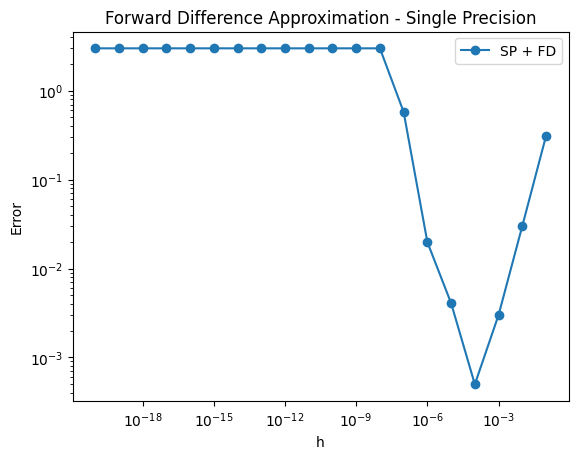

In [17]:
plt.plot(h,eps_fd,'o-',label='SP + FD')
plt.xscale("log")
plt.yscale("log")
plt.title("Forward Difference Approximation - Single Precision")
plt.xlabel("h")
plt.ylabel("Error")
plt.legend()

#### Case 2:  Double Precision floating point + forward difference approximation

In [18]:
h = np.zeros(n)
fx = np.zeros(n)
fx_plus_h = np.zeros(n)
fprime_exact = np.zeros(n)
fprime_fd_double = np.zeros(n)

eps_fd_double = np.zeros(n)


In [19]:
for i in range(0,n):

    hpower=i-n
    h[i]=10**int(hpower)
    fprime_exact[i]=3.0e+00*xval*xval
    fx[i]=xval*xval*xval
    fx_plus_h[i]=(xval+h[i])*(xval+h[i])*(xval+h[i]);

    fprime_fd_double[i]=(fx_plus_h[i]-fx[i])/(h[i]);

    eps_fd_double[i]=np.abs(fprime_exact[i]-fprime_fd_double[i]);

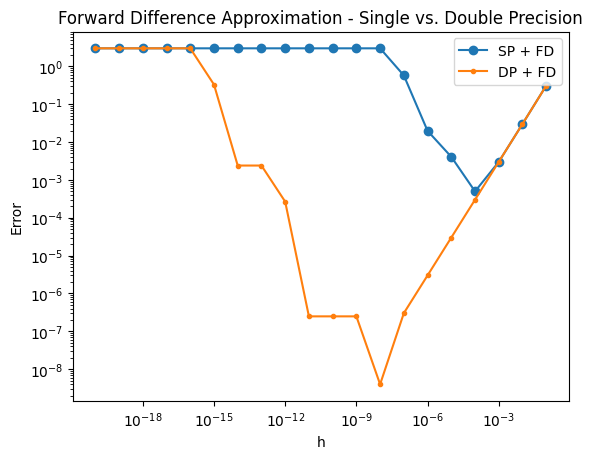

In [20]:
plt.plot(h,eps_fd,'o-',label='SP + FD')
plt.plot(h,eps_fd_double,'.-',label='DP + FD')
plt.xscale("log")
plt.yscale("log")
plt.title("Forward Difference Approximation - Single vs. Double Precision")
plt.xlabel("h")
plt.ylabel("Error")
plt.legend()

#### Case 3:  Single Precision floating point + centered difference approximation

The centered difference approximation to the derivative is given by

$$f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}$$

In [21]:
h = np.zeros(n,dtype=np.float32)
fx_plus_h = np.zeros(n,dtype=np.float32)
fx_minus_h = np.zeros(n,dtype=np.float32)
fprime_exact = np.zeros(n,dtype=np.float32)
fprime_cd = np.zeros(n,dtype=np.float32)

eps_cd = np.zeros(n,dtype=np.float32)


In [22]:
for i in range(0,n):

    hpower=i-n
    h[i]=10**int(hpower)
    fprime_exact[i]=3.0e+00*xval*xval
    fx_minus_h[i]=(xval-h[i])*(xval-h[i])*(xval-h[i])
    fx_plus_h[i]=(xval+h[i])*(xval+h[i])*(xval+h[i])

    fprime_cd[i]=(fx_plus_h[i]-fx_minus_h[i])/(2.0*h[i]);

    eps_cd[i]=np.abs(fprime_exact[i]-fprime_cd[i]);

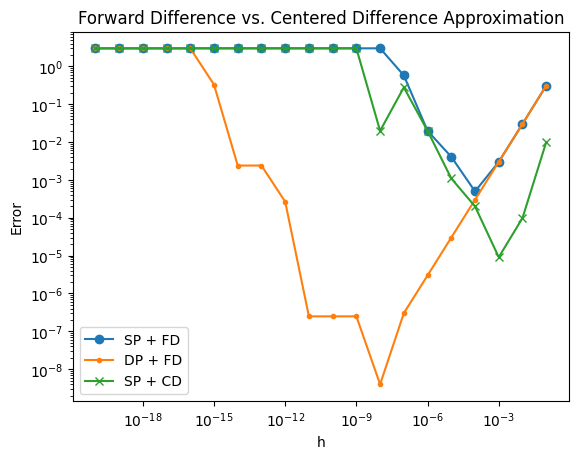

In [23]:
plt.plot(h,eps_fd,'o-',label='SP + FD')
plt.plot(h,eps_fd_double,'.-',label='DP + FD')
plt.plot(h,eps_cd,'x-',label='SP + CD')
plt.xscale("log")
plt.yscale("log")
plt.title("Forward Difference vs. Centered Difference Approximation")
plt.xlabel("h")
plt.ylabel("Error")
plt.legend()

#### Case 4:  Double Precision floating point + centered difference approximation

In [24]:
h = np.zeros(n)
fx_plus_h = np.zeros(n)
fx_minus_h = np.zeros(n)
fprime_exact = np.zeros(n)
fprime_cd_double = np.zeros(n)

eps_cd_double = np.zeros(n)


In [25]:
for i in range(0,n):

    hpower=i-n
    h[i]=10**int(hpower)
    fprime_exact[i]=3.0e+00*xval*xval
    fx_minus_h[i]=(xval-h[i])*(xval-h[i])*(xval-h[i])
    fx_plus_h[i]=(xval+h[i])*(xval+h[i])*(xval+h[i])

    fprime_cd_double[i]=(fx_plus_h[i]-fx_minus_h[i])/(2.0*h[i]);

    eps_cd_double[i]=np.abs(fprime_exact[i]-fprime_cd_double[i]);

Text(0, 0.5, 'Error')

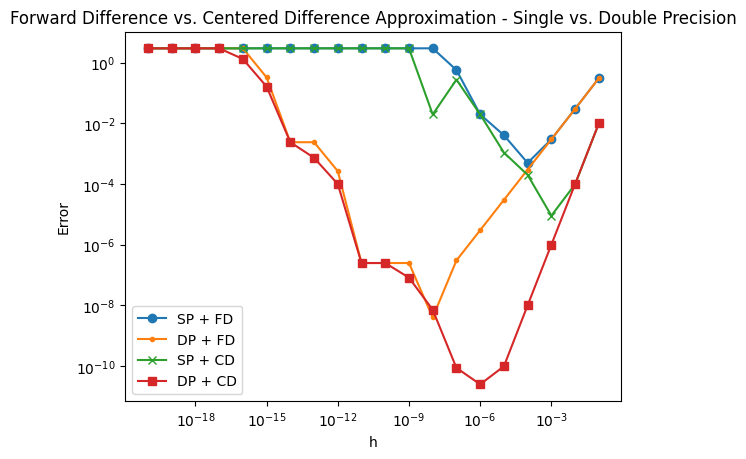

In [26]:
plt.plot(h,eps_fd,'o-',label='SP + FD') # single precision, forward difference
plt.plot(h,eps_fd_double,'.-',label='DP + FD') # double precision, forward difference
plt.plot(h,eps_cd,'x-',label='SP + CD') # single precision, centered difference
plt.plot(h,eps_cd_double,'s-',label='DP + CD') # double precision, centered difference
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Forward Difference vs. Centered Difference Approximation - Single vs. Double Precision")
plt.xlabel("h")
plt.ylabel("Error")

#### Conclusion

The forward difference approximation to the derivative is first order accurate.

The centered difference approximation to the derivative is second order accurate.

The error in the approximation is proportional to $h$ for the forward difference approximation and proportional to $h^2$ for the centered difference approximation.

The error in the approximation is inversely proportional to the precision of the floating point arithmetic. That is, the error in the approximation is smaller for double precision than for single precision.

### Use double precision!!! It is more accurate and not much slower than single precision. It is the default in Python, but in other languages one must specify that double precision is desired.

### The algorithm used to evaluate the derivative is important.  The centered difference approximation is more accurate than the forward difference approximation.





#### Case 5:  Investigation of the function y=x$^3$

Another interesting question that we can ask is: does it matter where we evaluate the derivative?  For example, does it matter if we evaluate the derivative at $x=0$ or, as we did above, at $x=1$?  We can investigate this question by plotting the error in the derivative as a function of $x$.

We begin by evaluating the derivative, and the function, over a range of $x$, for a large numer of points.  We choose non-"nice" values of the end-points and the number of points to avoid any special cases (like $x=0$, exactly).

We will evaluate the derivative using both the forward difference, backward difference, and centered difference approximations.

The forward difference approximation to the derivative is given by

$$f'(x) \approx \frac{f(x+h)-f(x)}{h}$$

The backward difference approximation to the derivative is given by

$$f'(x) \approx \frac{f(x)-f(x-h)}{h}$$

The centered difference approximation to the derivative is given by

$$f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}$$

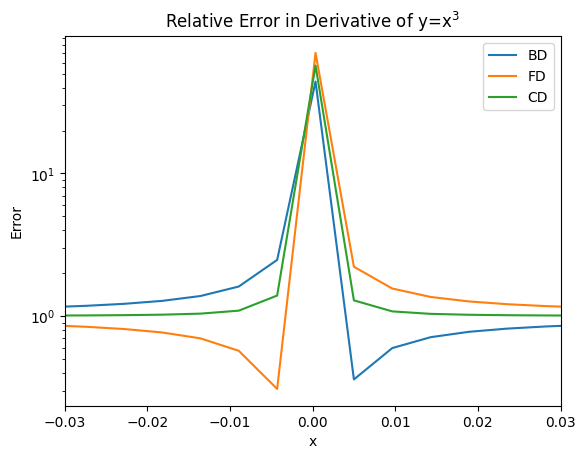

In [14]:
npts = 1511
xlow = -3.5
xhigh = 3.51
x = np.linspace(xlow,xhigh,npts)
y = x**3
yp = 3.0*x**2

#plt.plot(x,y)
#plt.plot(x,yp/yp)

dx = (xhigh-xlow)/(npts-1)

yp_backward = np.zeros(npts)
yp_backward[0] = 3.0*x[0]**2

for i in range(1,npts):
    yp_backward[i] = (y[i]-y[i-1])/dx
    
yp_forward = np.zeros(npts)
yp_forward[npts-1] = 3.0*x[npts-1]**2

for i in range(0,npts-1):
    yp_forward[i] = (y[i+1]-y[i])/dx

yp_center = np.zeros(npts)
yp_center[0] = 3.0*x[0]**2
yp_center[npts-1] = 3.0*x[npts-1]**2

for i in range(1,npts-1):
    yp_center[i] = (y[i+1]-y[i-1])/(2.0*dx)

plt.plot(x,np.abs(yp_backward/yp),label="BD")
plt.plot(x,np.abs(yp_forward/yp),label="FD")
plt.plot(x,np.abs(yp_center/yp),label="CD")
plt.yscale("log")
plt.xlim(-.03,.03)
plt.title("Relative Error in Derivative of y=x$^3$")
plt.xlabel("x")
plt.ylabel("Error")
plt.legend()